# Cognifyz Technologies - Data Science Internship
## Level 1: Data Exploration, Preprocessing, Descriptive & Geospatial Analysis

**Make sure `Dataset_.csv` is in the same folder as this notebook before running.**

## Setup: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
%matplotlib inline

## Load the Dataset

In [2]:
df = pd.read_csv("Dataset_.csv")
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,Average Cost for two,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",1100,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,1200,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",4000,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",1500,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",1500,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


---
## Task 1: Data Exploration and Preprocessing
### 1.1 Number of rows and columns

In [3]:
print(f"Number of rows    : {df.shape[0]}")
print(f"Number of columns : {df.shape[1]}")
print(f"\nColumn names:\n{list(df.columns)}")

Number of rows    : 9551
Number of columns : 21

Column names:
['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address', 'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines', 'Average Cost for two', 'Currency', 'Has Table booking', 'Has Online delivery', 'Is delivering now', 'Switch to order menu', 'Price range', 'Aggregate rating', 'Rating color', 'Rating text', 'Votes']


### 1.2 Check for missing values

In [4]:
missing = df.isnull().sum()
missing = missing[missing > 0]
print(missing if not missing.empty else "No missing values found.")

Cuisines    9
dtype: int64


### 1.3 Handle missing values
The `Cuisines` column has a few missing values. We'll fill them with `'Not Available'`.

In [5]:
df["Cuisines"] = df["Cuisines"].fillna("Not Available")
print("Missing values after handling:", df.isnull().sum().sum())

Missing values after handling: 0


### 1.4 Data type conversion

In [6]:
print(df.dtypes)

for col in ["Has Table booking", "Has Online delivery", "Is delivering now", "Switch to order menu"]:
    df[col] = df[col].astype("category")

print("\nConverted Yes/No columns to category dtype.")

Restaurant ID             int64
Restaurant Name             str
Country Code              int64
City                        str
Address                     str
Locality                    str
Locality Verbose            str
Longitude               float64
Latitude                float64
Cuisines                    str
Average Cost for two      int64
Currency                    str
Has Table booking           str
Has Online delivery         str
Is delivering now           str
Switch to order menu        str
Price range               int64
Aggregate rating        float64
Rating color                str
Rating text                 str
Votes                     int64
dtype: object

Converted Yes/No columns to category dtype.


### 1.5 Distribution of the target variable (Aggregate rating) & class imbalance

In [7]:
print(df["Aggregate rating"].describe())

rating_zero = (df["Aggregate rating"] == 0).sum()
print(f"\nRestaurants with rating = 0 (not yet rated): {rating_zero} ({rating_zero/len(df)*100:.2f}%)")

print("\nRating text category counts:")
print(df["Rating text"].value_counts())

count    9551.000000
mean        2.666370
std         1.516378
min         0.000000
25%         2.500000
50%         3.200000
75%         3.700000
max         4.900000
Name: Aggregate rating, dtype: float64

Restaurants with rating = 0 (not yet rated): 2148 (22.49%)

Rating text category counts:
Rating text
Average      3737
Not rated    2148
Good         2100
Very Good    1079
Excellent     301
Poor          186
Name: count, dtype: int64


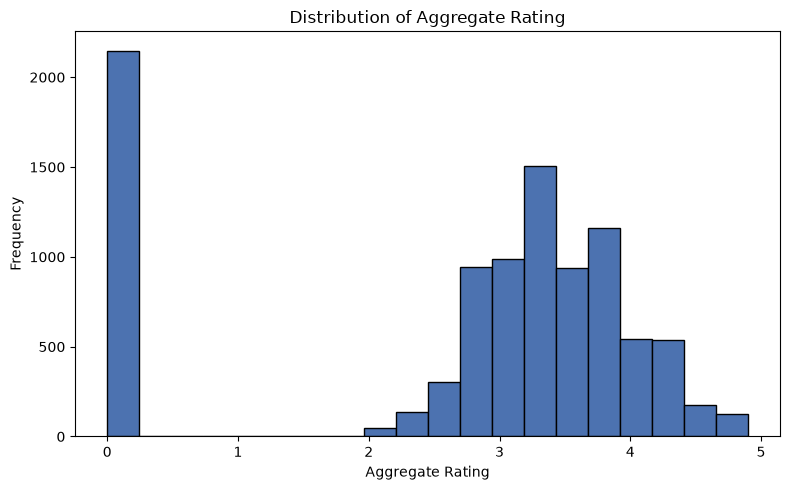

In [8]:
plt.figure(figsize=(8, 5))
plt.hist(df["Aggregate rating"], bins=20, color="#4C72B0", edgecolor="black")
plt.title("Distribution of Aggregate Rating")
plt.xlabel("Aggregate Rating")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

**Observation:** A large number of restaurants have an Aggregate rating of 0 (not yet rated), creating a strong class imbalance compared to bands like 'Excellent' or 'Poor'.

---
## Task 2: Descriptive Analysis
### 2.1 Basic statistical measures for numerical columns

In [9]:
numeric_cols = ["Average Cost for two", "Price range", "Aggregate rating", "Votes"]
df[numeric_cols].describe()

,Average Cost for two,Price range,Aggregate rating,Votes
count,9551.000000,9551.000000,9551.000000,9551.000000
mean,1199.210763,1.804837,2.666370,156.909748
std,16121.183073,0.905609,1.516378,430.169145
min,0.000000,1.000000,0.000000,0.000000
25%,250.000000,1.000000,2.500000,5.000000
50%,400.000000,2.000000,3.200000,31.000000
75%,700.000000,2.000000,3.700000,131.000000
max,800000.000000,4.000000,4.900000,10934.000000


### 2.2 Distribution of categorical variables

In [10]:
print("Top 10 Country Codes:")
print(df["Country Code"].value_counts().head(10))

print("\nTop 10 Cities:")
print(df["City"].value_counts().head(10))

cuisine_series = df["Cuisines"].str.split(",").explode().str.strip()
top_cuisines = cuisine_series.value_counts().head(10)
print("\nTop 10 Cuisines:")
print(top_cuisines)

Top 10 Country Codes:
Country Code
1      8652
216     434
215      80
30       60
214      60
189      60
148      40
208      34
14       24
162      22
Name: count, dtype: int64

Top 10 Cities:
City
New Delhi       5473
Gurgaon         1118
Noida           1080
Faridabad        251
Ghaziabad         25
Ahmedabad         21
Amritsar          21
Bhubaneshwar      21
Guwahati          21
Lucknow           21
Name: count, dtype: int64

Top 10 Cuisines:
Cuisines
North Indian    3960
Chinese         2735
Fast Food       1986
Mughlai          995
Italian          764
Bakery           745
Continental      736
Cafe             703
Desserts         653
South Indian     636
Name: count, dtype: int64


### 2.3 Top cuisines and cities with the highest number of restaurants

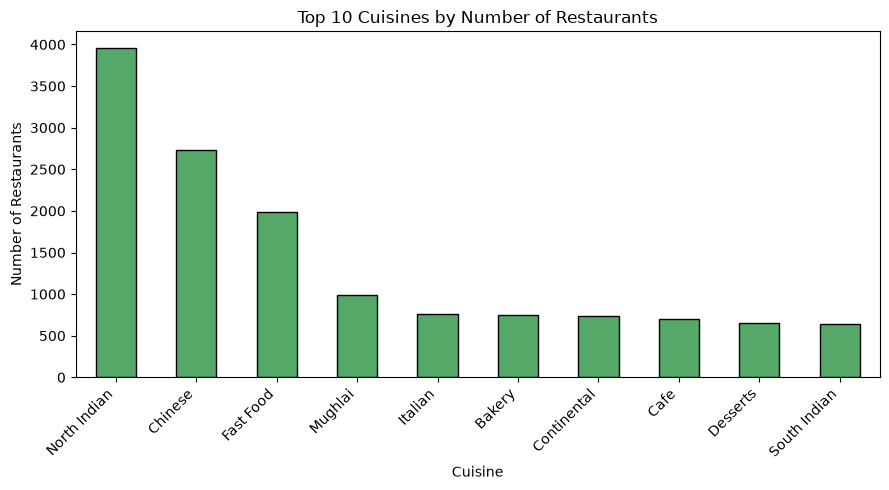

In [11]:
plt.figure(figsize=(9, 5))
top_cuisines.plot(kind="bar", color="#55A868", edgecolor="black")
plt.title("Top 10 Cuisines by Number of Restaurants")
plt.xlabel("Cuisine")
plt.ylabel("Number of Restaurants")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

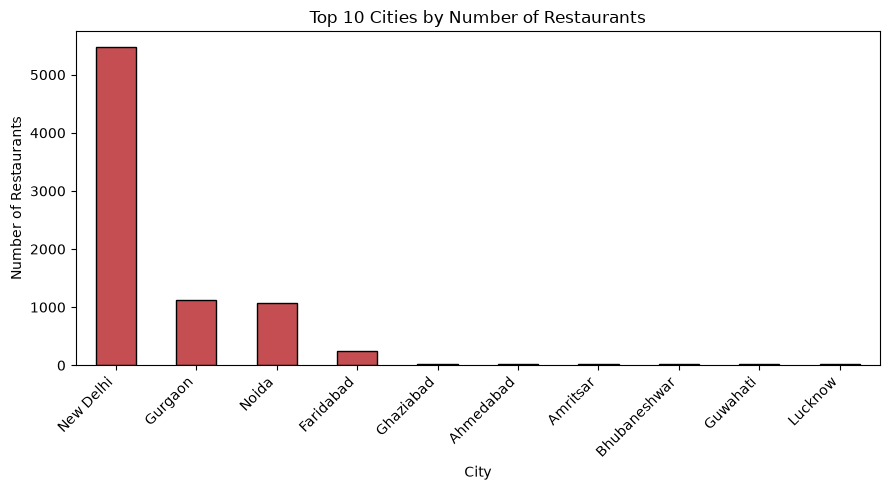

Top cuisine overall: North Indian (3960 restaurants)
Top city overall: New Delhi (5473 restaurants)


In [12]:
top_cities = df["City"].value_counts().head(10)

plt.figure(figsize=(9, 5))
top_cities.plot(kind="bar", color="#C44E52", edgecolor="black")
plt.title("Top 10 Cities by Number of Restaurants")
plt.xlabel("City")
plt.ylabel("Number of Restaurants")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print(f"Top cuisine overall: {top_cuisines.index[0]} ({top_cuisines.iloc[0]} restaurants)")
print(f"Top city overall: {top_cities.index[0]} ({top_cities.iloc[0]} restaurants)")

---
## Task 3: Geospatial Analysis
### 3.1 Visualize restaurant locations using latitude & longitude

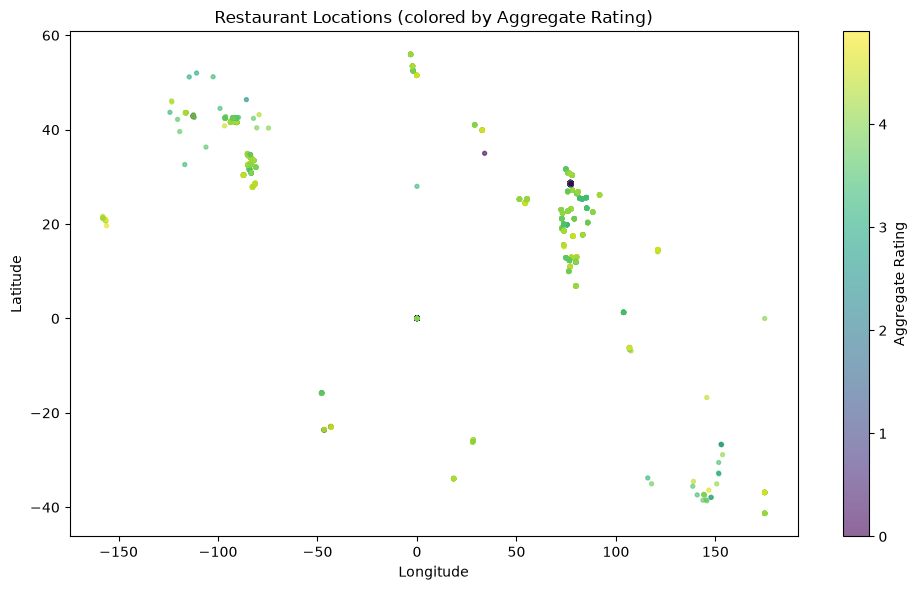

In [13]:
plt.figure(figsize=(10, 6))
scatter = plt.scatter(df["Longitude"], df["Latitude"], c=df["Aggregate rating"],
                       cmap="viridis", s=8, alpha=0.6)
plt.colorbar(scatter, label="Aggregate Rating")
plt.title("Restaurant Locations (colored by Aggregate Rating)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.tight_layout()
plt.show()

### 3.2 Distribution of restaurants across cities/countries

In [14]:
df["Country Code"].value_counts().head(10)

Country Code
1      8652
216     434
215      80
30       60
214      60
189      60
148      40
208      34
14       24
162      22
Name: count, dtype: int64

### 3.3 Correlation between location and rating

In [15]:
corr_lat = df["Latitude"].corr(df["Aggregate rating"])
corr_long = df["Longitude"].corr(df["Aggregate rating"])
print(f"Correlation (Latitude vs Rating)  : {corr_lat:.4f}")
print(f"Correlation (Longitude vs Rating) : {corr_long:.4f}")

Correlation (Latitude vs Rating)  : 0.0005
Correlation (Longitude vs Rating) : -0.1168


**Observation:** Correlation values are close to zero — no strong linear relationship between raw coordinates and rating. Rating differences are more likely driven by city-level factors than geography itself.

---
### Level 1 Complete!